In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score

from IPython.display import display


# TCN validation diagnostics


In [2]:
data_file = "../processed_data/finalized_feature_data_2024-03-01_2026-05-02.csv"
feature_data = (
    pd.read_csv(data_file, parse_dates=["timestamp_utc"])
    .set_index("timestamp_utc")
    .sort_index()
)

feature_data["Day_of_week_sin"] = np.sin(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Day_of_week_cos"] = np.cos(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Month_sin"] = np.sin(2 * np.pi * feature_data["Month"] / 12)
feature_data["Month_cos"] = np.cos(2 * np.pi * feature_data["Month"] / 12)

observed_cols = [column for column in feature_data.columns if column.startswith("observed_")]
forecast_cols = [column for column in feature_data.columns if column.startswith("forecast_")]

feature_combined = feature_data.drop(columns=forecast_cols).copy()
forecast_data = feature_data[forecast_cols].copy()

display(feature_data.shape)
display(feature_combined.shape)
display(forecast_data.shape)
display(feature_combined.columns)
display(forecast_data.columns)


(18988, 63)

(18988, 43)

(18988, 20)

Index(['Hour', 'Day_of_week', 'Month', 'Is_weekend', 'Hour_sin', 'Hour_cos',
       'Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Lignite', 'Hard_coal', 'Fossil_gas', 'Hydro_pump_stor',
       'Other_conv', 'Price', 'Negative_price',
       'observed_north_wind__wind_speed_100m_avg',
       'observed_north_wind__wind_direction_100m_sin_avg',
       'observed_north_wind__wind_direction_100m_cos_avg',
       'observed_northeast_wind__wind_speed_100m_avg',
       'observed_northeast_wind__wind_direction_100m_sin_avg',
       'observed_northeast_wind__wind_direction_100m_cos_avg',
       'observed_offshore_north_sea__wind_speed_100m_avg',
       'observed_offshore_north_sea__wind_direction_100m_sin_avg',
       'observed_offshore_north_sea__wind_direction_100m_cos_avg',
       'observed_offshore_baltic_sea__wind_speed_100m_avg',
       'observed_offshore_baltic_sea__wind_direction_100m_sin_avg',
       'observed_offshore_baltic_sea__wind_direction_1

Index(['forecast_north_wind__wind_speed_100m_avg',
       'forecast_north_wind__wind_direction_100m_sin_avg',
       'forecast_north_wind__wind_direction_100m_cos_avg',
       'forecast_northeast_wind__wind_speed_100m_avg',
       'forecast_northeast_wind__wind_direction_100m_sin_avg',
       'forecast_northeast_wind__wind_direction_100m_cos_avg',
       'forecast_offshore_north_sea__wind_speed_100m_avg',
       'forecast_offshore_north_sea__wind_direction_100m_sin_avg',
       'forecast_offshore_north_sea__wind_direction_100m_cos_avg',
       'forecast_offshore_baltic_sea__wind_speed_100m_avg',
       'forecast_offshore_baltic_sea__wind_direction_100m_sin_avg',
       'forecast_offshore_baltic_sea__wind_direction_100m_cos_avg',
       'forecast_south_solar__solar_radiation_avg',
       'forecast_south_solar__cloud_cover_avg',
       'forecast_south_solar__sunshine_duration_avg',
       'forecast_east_solar__solar_radiation_avg',
       'forecast_east_solar__cloud_cover_avg',
       'f

In [3]:
# Basic timestamp checks.
for name, df in {"feature_combined": feature_combined, "forecast_data": forecast_data}.items():
    if df.index.has_duplicates:
        raise ValueError(f"{name} has duplicated timestamps")

    hourly_steps = df.index.to_series().sort_values().diff().dropna()
    if not hourly_steps.eq(pd.Timedelta(hours=1)).all():
        raise ValueError(f"{name} is not continuous hourly data")


## Forecast-model input

The TCN uses SMARD and price history ending at `t-24`, followed by the deployable forecast-weather path from `t-23` through target hour `t`.


In [4]:
# Config
lookback = 48
valid_start = pd.Timestamp("2025-07-01", tz="UTC")
test_start = pd.Timestamp("2025-12-01", tz="UTC")

tcn_channels = (64, 64, 64, 64)
kernel_size = 3
dropout = 0.3
learning_rate = 0.001

batch_size = 64
epochs = 50
patience = 3

focal_alpha = 0.75
focal_gamma = 2.0


In [5]:
# Model input tables. Target time is t; SMARD and price history end at t-24.
target = feature_combined["Negative_price"].astype(int).sort_index()

calendar_cols = [
    "Hour",
    "Day_of_week",
    "Month",
    "Is_weekend",
    "Hour_sin",
    "Hour_cos",
    "Day_of_week_sin",
    "Day_of_week_cos",
    "Month_sin",
    "Month_cos",
]

observed_cols = [c for c in feature_combined.columns if c.startswith("observed_")]
forecast_cols = [c for c in forecast_data.columns if c.startswith("forecast_")]
smard_input_cols = [
    c for c in feature_combined.columns
    if c not in calendar_cols + ["Negative_price"] + observed_cols
]

observed_weather = feature_combined[observed_cols].rename(columns=lambda c: c.replace("observed_", ""))
forecast_weather = forecast_data[forecast_cols].rename(columns=lambda c: c.replace("forecast_", ""))

if sorted(observed_weather.columns) != sorted(forecast_weather.columns):
    raise ValueError("Observed and forecast weather columns do not match after removing prefixes")

weather_cols = observed_weather.columns.tolist()
feature_cols = calendar_cols + smard_input_cols + weather_cols

past_raw = pd.concat(
    [feature_combined[calendar_cols], feature_combined[smard_input_cols], observed_weather],
    axis=1,
).sort_index()

# At t-23...t, only calendar and forecast weather are available.
forecast_future_raw = (
    feature_combined[calendar_cols]
    .join(forecast_weather, how="inner")
    .reindex(columns=feature_cols)
    .sort_index()
)

# Short aliases used by the diagnostic cells below.
df = past_raw
df_forecast = forecast_future_raw

pd.DataFrame({
    "table": ["past_raw", "forecast_future_raw"],
    "shape": [past_raw.shape, forecast_future_raw.shape],
    "start": [past_raw.index.min(), forecast_future_raw.index.min()],
    "end": [past_raw.index.max(), forecast_future_raw.index.max()],
})


,table,shape,start,end
0,past_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00
1,forecast_future_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00


In [6]:
# Scale with training-period statistics only.
train_rows = past_raw[past_raw.index < valid_start].reindex(columns=feature_cols)
feature_mean = train_rows.mean()
feature_std = train_rows.std().replace(0, 1).fillna(1)

def scale_features(frame):
    return ((frame.reindex(columns=feature_cols) - feature_mean) / feature_std).fillna(0.0)

past_scaled = scale_features(past_raw)
forecast_future_scaled = scale_features(forecast_future_raw)


In [7]:
# Build sequences. Past part is t-(24+lookback-1)...t-24.
# If future_X is passed, append the deployable weather path t-23...t.
def build_sequences(X, y, future_X=None, lookback=24):
    Xs, ys, times = [], [], []

    X_values = X.to_numpy(dtype=np.float32)
    X_start = X.index.min()

    if future_X is not None:
        future_values = future_X.to_numpy(dtype=np.float32)
        future_start_time = future_X.index.min()

    for t in y.index:
        past_start = t - pd.Timedelta(hours=24 + lookback - 1)
        past_end = t - pd.Timedelta(hours=24)

        start_pos = int((past_start - X_start).total_seconds() // 3600)
        end_pos = int((past_end - X_start).total_seconds() // 3600) + 1

        if start_pos < 0 or end_pos > len(X_values):
            continue

        seq = X_values[start_pos:end_pos]
        if len(seq) != lookback:
            continue

        if future_X is not None:
            future_start = t - pd.Timedelta(hours=23)
            future_start_pos = int((future_start - future_start_time).total_seconds() // 3600)
            future_end_pos = int((t - future_start_time).total_seconds() // 3600) + 1

            if future_start_pos < 0 or future_end_pos > len(future_values):
                continue

            future_seq = future_values[future_start_pos:future_end_pos]
            if len(future_seq) != 24:
                continue

            seq = np.vstack([seq, future_seq])

        Xs.append(seq)
        ys.append(y.loc[t])
        times.append(t)

    return np.array(Xs), np.array(ys, dtype=np.float32), pd.DatetimeIndex(times)


In [8]:
# Build the forecast-model sequences and chronological splits.
X_forecast, y_forecast, times_forecast = build_sequences(
    past_scaled,
    target,
    future_X=forecast_future_scaled,
    lookback=lookback,
)

train_mask = times_forecast < valid_start
valid_mask = (times_forecast >= valid_start) & (times_forecast < test_start)
test_mask = times_forecast >= test_start

forecast_dataset = {
    "X_train": X_forecast[train_mask],
    "y_train": y_forecast[train_mask],
    "X_valid": X_forecast[valid_mask],
    "y_valid": y_forecast[valid_mask],
    "X_test": X_forecast[test_mask],
    "y_test": y_forecast[test_mask],
}

dataset_summary = pd.Series({
    "lookback": lookback,
    "train": len(forecast_dataset["y_train"]),
    "valid": len(forecast_dataset["y_valid"]),
    "test": len(forecast_dataset["y_test"]),
    "sequence_shape": X_forecast.shape[1:],
    "start": times_forecast.min(),
    "end": times_forecast.max(),
})
display(dataset_summary.to_frame("forecast_model"))


,forecast_model
lookback,48
train,11617
valid,3672
test,3628
sequence_shape,"(72, 42)"
start,2024-03-03 23:00:00+00:00
end,2026-05-01 03:00:00+00:00


## TCN model


In [9]:
# TCN structure
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        if in_channels != out_channels:
            self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.downsample = nn.Identity()

        self.final_relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        return self.final_relu(out + self.downsample(x))


class CurtailmentTCN(nn.Module):
    def __init__(self, input_dim, channels=(64, 64, 64, 64), kernel_size=3, dropout=0.1):
        super().__init__()

        layers = []
        in_channels = input_dim
        for i, out_channels in enumerate(channels):
            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    dilation=2 ** i,
                    dropout=dropout,
                )
            )
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], 1)

    def forward(self, x):
        # Conv1d expects batch, features, time.
        x = x.transpose(1, 2)
        tcn_out = self.tcn(x)
        last_step = tcn_out[:, :, -1]
        return self.fc(last_step).squeeze(-1)


In [10]:
# Dataloaders
def make_loader(X, y, shuffle):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


In [11]:
# Training and evaluation helpers
def binary_focal_loss_with_logits(logits, targets, gamma=0.0, alpha=None, pos_weight=None):
    targets = targets.to(device=logits.device, dtype=logits.dtype)
    bce = torch.nn.functional.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=pos_weight,
        reduction="none",
    )

    if gamma and gamma > 0:
        probabilities = torch.sigmoid(logits)
        p_t = targets * probabilities + (1.0 - targets) * (1.0 - probabilities)
        bce = (1.0 - p_t).pow(gamma) * bce

    if alpha is not None:
        alpha = torch.as_tensor(alpha, device=logits.device, dtype=logits.dtype)
        alpha_t = targets * alpha + (1.0 - targets) * (1.0 - alpha)
        bce = alpha_t * bce

    return bce.mean()


def make_loss(pos_weight, focal_alpha=None, focal_gamma=0.0):
    def criterion(logits, targets):
        return binary_focal_loss_with_logits(
            logits,
            targets,
            gamma=focal_gamma,
            alpha=focal_alpha,
            pos_weight=pos_weight,
        )

    return criterion


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return float(np.mean(losses))


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())

    return float(np.mean(losses))


def predict_probabilities(model, loader, device):
    model.eval()
    probabilities, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(device))
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(y_batch.numpy())

    return np.concatenate(probabilities), np.concatenate(targets)


def threshold_sweep(y_true, probabilities):
    thresholds = np.linspace(0.05, 0.95, 91)
    f1_scores = [f1_score(y_true, probabilities >= t, zero_division=0) for t in thresholds]
    best_index = int(np.argmax(f1_scores))
    return thresholds[best_index], f1_scores[best_index]


def plot_threshold_and_pr_curve(y_true, probabilities, threshold=None, title="TCN validation"):
    precision, recall, pr_thresholds = precision_recall_curve(y_true, probabilities)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    best_index = int(np.argmax(f1_scores[:-1]))
    best_threshold = pr_thresholds[best_index]
    best_f1 = f1_scores[best_index]
    selected_threshold = best_threshold if threshold is None else threshold
    pr_auc = average_precision_score(y_true, probabilities)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(pr_thresholds, f1_scores[:-1])
    axes[0].axvline(selected_threshold, color="red", linestyle="--", label=f"threshold = {selected_threshold:.3f}")
    axes[0].set(xlabel="Probability threshold", ylabel="F1 score", title=f"{title}: F1 vs threshold")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(np.mean(y_true), color="gray", linestyle="--", label="Positive-rate baseline")
    axes[1].set(xlabel="Recall", ylabel="Precision", title=f"{title}: PR curve")
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return {"best_threshold": best_threshold, "best_f1": best_f1, "pr_auc": pr_auc}


In [12]:
# Train one TCN and return probabilities needed by the diagnostics.
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_random_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_tcn(data, config):
    set_random_seed(config["seed"])
    device = get_device()

    model = CurtailmentTCN(
        input_dim=data["X_train"].shape[2],
        channels=config["channels"],
        kernel_size=config["kernel_size"],
        dropout=config["dropout"],
    ).to(device)

    num_pos = data["y_train"].sum()
    num_neg = len(data["y_train"]) - num_pos
    pos_weight = torch.tensor(
        [num_neg / max(num_pos, 1)],
        dtype=torch.float32,
        device=device,
    )
    criterion = make_loss(
        pos_weight=pos_weight,
        focal_alpha=config["focal_alpha"],
        focal_gamma=config["focal_gamma"],
    )
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

    train_loader = make_loader(data["X_train"], data["y_train"], shuffle=True)
    train_eval_loader = make_loader(data["X_train"], data["y_train"], shuffle=False)
    valid_loader = make_loader(data["X_valid"], data["y_valid"], shuffle=False)

    best_state = None
    best_epoch = 0
    best_valid_pr_auc = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(config["epochs"]):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_prob, valid_true = predict_probabilities(model, valid_loader, device)
        valid_pr_auc = average_precision_score(valid_true, valid_prob)
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "valid_PR_AUC": valid_pr_auc,
        })

        if valid_pr_auc > best_valid_pr_auc:
            best_valid_pr_auc = valid_pr_auc
            best_epoch = epoch + 1
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config["patience"]:
            break

    model.load_state_dict(best_state)
    train_prob, train_true = predict_probabilities(model, train_eval_loader, device)
    valid_prob, valid_true = predict_probabilities(model, valid_loader, device)

    return {
        "best_epoch": best_epoch,
        "best_valid_PR_AUC": best_valid_pr_auc,
        "train_true": train_true,
        "train_prob": train_prob,
        "valid_true": valid_true,
        "valid_prob": valid_prob,
        "history": pd.DataFrame(history),
    }


## Train TCN ensemble


In [13]:
seeds = [1, 2, 3]
config = {
    "channels": tcn_channels,
    "kernel_size": kernel_size,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "epochs": epochs,
    "patience": patience,
    "focal_alpha": 0.75,
    "focal_gamma": 2.0,
}

tcn_predictions = {}
tcn_results = []
for seed in seeds:
    run_config = {**config, "seed": seed}
    prediction = train_tcn(forecast_dataset, run_config)
    tcn_predictions[seed] = prediction
    tcn_results.append(prediction["valid_prob"])
    print(
        f"TCN seed {seed}: best_epoch={prediction['best_epoch']}, "
        f"valid_PR_AUC={prediction['best_valid_PR_AUC']:.4f}"
    )

results = pd.DataFrame(tcn_results, index=seeds)
results.index.name = "seed"
display(results)


TCN seed 1: best_epoch=1, valid_PR_AUC=0.7186
TCN seed 2: best_epoch=3, valid_PR_AUC=0.7753
TCN seed 3: best_epoch=2, valid_PR_AUC=0.7554


,0,1,2,3,4,5,6,7,8,9,...,3662,3663,3664,3665,3666,3667,3668,3669,3670,3671
seed,,,,,,,,,,,,,,,,,,,,,
1,0.064382,0.084117,0.096637,0.138763,0.150390,0.219664,0.365902,0.606272,0.755197,0.822701,...,0.595470,0.487650,0.440783,0.424906,0.399658,0.386430,0.362527,0.371819,0.354982,0.298959
2,0.032753,0.036496,0.035428,0.042027,0.049814,0.079609,0.185187,0.341385,0.552197,0.659946,...,0.410454,0.285634,0.244971,0.235192,0.216504,0.222997,0.212525,0.223513,0.214363,0.201168
3,0.055383,0.087392,0.113073,0.145753,0.140025,0.217234,0.373444,0.544194,0.729947,0.818667,...,0.582296,0.522306,0.479896,0.469558,0.379716,0.370761,0.367688,0.370975,0.348976,0.360963


In [14]:
# Evaluate the mean TCN probability across seeds.
avg_scores = results.mean(axis=0).to_numpy()
y_true = forecast_dataset["y_valid"]

thresholds = np.unique(avg_scores)
threshold_f1s = np.array([
    f1_score(y_true, avg_scores >= threshold, zero_division=0)
    for threshold in thresholds
])

best_idx = int(threshold_f1s.argmax())
best_threshold = thresholds[best_idx]

tcn_avg_preds = (avg_scores >= best_threshold).astype(int)
tcn_avg_precision = precision_score(y_true, tcn_avg_preds, zero_division=0)
tcn_avg_recall = recall_score(y_true, tcn_avg_preds, zero_division=0)
tcn_avg_f1 = f1_score(y_true, tcn_avg_preds, zero_division=0)
tcn_avg_pr_auc = average_precision_score(y_true, avg_scores)

display(pd.Series({
    "best_threshold": best_threshold,
    "precision": tcn_avg_precision,
    "recall": tcn_avg_recall,
    "f1": tcn_avg_f1,
    "pr_auc": tcn_avg_pr_auc,
}).to_frame("TCN validation"))


,TCN validation
best_threshold,0.809769
precision,0.716667
recall,0.701087
f1,0.708791
pr_auc,0.774874


## Diagnostic


In [15]:
# TCN train-set FP/FN summary using the validation-selected threshold.
from IPython.display import display

tcn_train_times = times_forecast[train_mask]
tcn_train_y = y_forecast[train_mask]
for seed in seeds:
    assert np.array_equal(tcn_predictions[seed]["train_true"], tcn_train_y)
tcn_train_scores = pd.DataFrame([
    tcn_predictions[seed]["train_prob"]
    for seed in seeds
], index=seeds).mean(axis=0).to_numpy()
tcn_train_pred = (tcn_train_scores >= best_threshold).astype(int)

tcn_train_diag = pd.DataFrame({
    "timestamp": tcn_train_times,
    "y_true": tcn_train_y.astype(int),
    "y_prob": tcn_train_scores,
    "y_pred": tcn_train_pred,
})
tcn_train_diag["FP"] = (tcn_train_diag["y_pred"].eq(1) & tcn_train_diag["y_true"].eq(0)).astype(int)
tcn_train_diag["FN"] = (tcn_train_diag["y_pred"].eq(0) & tcn_train_diag["y_true"].eq(1)).astype(int)
tcn_train_diag["TP"] = (tcn_train_diag["y_pred"].eq(1) & tcn_train_diag["y_true"].eq(1)).astype(int)
tcn_train_diag["TN"] = (tcn_train_diag["y_pred"].eq(0) & tcn_train_diag["y_true"].eq(0)).astype(int)

tcn_train_total = pd.Series({
    "threshold_from_valid": best_threshold,
    "size": len(tcn_train_diag),
    "positive": int(tcn_train_diag["y_true"].sum()),
    "negative": int(tcn_train_diag["y_true"].eq(0).sum()),
    "TP": int(tcn_train_diag["TP"].sum()),
    "FP": int(tcn_train_diag["FP"].sum()),
    "FN": int(tcn_train_diag["FN"].sum()),
    "TN": int(tcn_train_diag["TN"].sum()),
    "1-precision": tcn_train_diag["FP"].sum() / max(tcn_train_diag["FP"].sum() + tcn_train_diag["TP"].sum(), 1),
    "1-recall": tcn_train_diag["FN"].sum() / max(tcn_train_diag["FN"].sum() + tcn_train_diag["TP"].sum(), 1),
    "f1": f1_score(tcn_train_diag["y_true"], tcn_train_diag["y_pred"], zero_division=0),
})

month = pd.DatetimeIndex(tcn_train_diag["timestamp"]).month
tcn_train_diag["season"] = np.select(
    [month.isin([12, 1, 2]), month.isin([3, 4, 5]), month.isin([6, 7, 8])],
    ["winter", "spring", "summer"],
    default="autumn",
)
tcn_train_diag["hour"] = pd.DatetimeIndex(tcn_train_diag["timestamp"]).hour

tcn_train_season = tcn_train_diag.groupby("season", sort=False).agg(
    size=("y_true", "size"),
    positive=("y_true", "sum"),
    FP=("FP", "sum"),
    FN=("FN", "sum"),
    TP=("TP", "sum"),
    TN=("TN", "sum"),
)
tcn_train_season["1-precision"] = tcn_train_season["FP"] / (tcn_train_season["FP"] + tcn_train_season["TP"]).replace(0, np.nan)
tcn_train_season["1-recall"] = tcn_train_season["FN"] / (tcn_train_season["FN"] + tcn_train_season["TP"]).replace(0, np.nan)
tcn_train_season["f1"] = 2 * tcn_train_season["TP"] / (2 * tcn_train_season["TP"] + tcn_train_season["FP"] + tcn_train_season["FN"]).replace(0, np.nan)

tcn_train_hour = tcn_train_diag.groupby("hour").agg(
    size=("y_true", "size"),
    positive=("y_true", "sum"),
    FP=("FP", "sum"),
    FN=("FN", "sum"),
    TP=("TP", "sum"),
    TN=("TN", "sum"),
)
tcn_train_hour["1-precision"] = tcn_train_hour["FP"] / (tcn_train_hour["FP"] + tcn_train_hour["TP"]).replace(0, np.nan)
tcn_train_hour["1-recall"] = tcn_train_hour["FN"] / (tcn_train_hour["FN"] + tcn_train_hour["TP"]).replace(0, np.nan)
tcn_train_hour_over_10pct = tcn_train_hour[(tcn_train_hour["positive"] > 20) & ((tcn_train_hour["1-precision"] > 0.10) | (tcn_train_hour["1-recall"] > 0.10))]

print("TCN train total")
display(tcn_train_total.to_frame("value"))
print("TCN train by season")
display(tcn_train_season)
print("TCN train by hour, 1-precision or 1-recall > 10%")
display(tcn_train_hour_over_10pct)


TCN train total


,value
threshold_from_valid,0.809769
size,11617.000000
positive,826.000000
negative,10791.000000
TP,618.000000
FP,121.000000
FN,208.000000
TN,10670.000000
1-precision,0.163735
1-recall,0.251816


TCN train by season


,size,positive,FP,FN,TP,TN,1-precision,1-recall,f1
season,,,,,,,,,
spring,4345,374,54,88,286,3917,0.158824,0.235294,0.801120
summer,2928,354,47,76,278,2527,0.144615,0.214689,0.818851
autumn,2184,76,20,36,40,2088,0.333333,0.473684,0.588235
winter,2160,22,0,8,14,2138,0.000000,0.363636,0.777778


TCN train by hour, 1-precision or 1-recall > 10%


,size,positive,FP,FN,TP,TN,1-precision,1-recall
hour,,,,,,,,
8,484,43,6,15,28,435,0.176471,0.348837
9,484,80,13,19,61,391,0.175676,0.237500
10,484,112,17,19,93,355,0.154545,0.169643
11,484,141,15,23,118,328,0.112782,0.163121
12,484,144,15,28,116,325,0.114504,0.194444
13,484,117,22,24,93,345,0.191304,0.205128
14,484,79,14,19,60,391,0.189189,0.240506
15,484,26,11,12,14,447,0.440000,0.461538


In [16]:
# TCN valid-set FP/FN summary using the validation-selected threshold.
from IPython.display import display

tcn_valid_times = times_forecast[valid_mask]
tcn_valid_y = y_forecast[valid_mask]
for seed in seeds:
    assert np.array_equal(tcn_predictions[seed]["valid_true"], tcn_valid_y)
tcn_valid_scores = avg_scores
tcn_valid_pred = (tcn_valid_scores >= best_threshold).astype(int)

tcn_valid_diag = pd.DataFrame({
    "timestamp": tcn_valid_times,
    "y_true": tcn_valid_y.astype(int),
    "y_prob": tcn_valid_scores,
    "y_pred": tcn_valid_pred,
})
tcn_valid_diag["FP"] = (tcn_valid_diag["y_pred"].eq(1) & tcn_valid_diag["y_true"].eq(0)).astype(int)
tcn_valid_diag["FN"] = (tcn_valid_diag["y_pred"].eq(0) & tcn_valid_diag["y_true"].eq(1)).astype(int)
tcn_valid_diag["TP"] = (tcn_valid_diag["y_pred"].eq(1) & tcn_valid_diag["y_true"].eq(1)).astype(int)
tcn_valid_diag["TN"] = (tcn_valid_diag["y_pred"].eq(0) & tcn_valid_diag["y_true"].eq(0)).astype(int)

tcn_valid_total = pd.Series({
    "threshold_from_valid": best_threshold,
    "size": len(tcn_valid_diag),
    "positive": int(tcn_valid_diag["y_true"].sum()),
    "negative": int(tcn_valid_diag["y_true"].eq(0).sum()),
    "TP": int(tcn_valid_diag["TP"].sum()),
    "FP": int(tcn_valid_diag["FP"].sum()),
    "FN": int(tcn_valid_diag["FN"].sum()),
    "TN": int(tcn_valid_diag["TN"].sum()),
    "1-precision": tcn_valid_diag["FP"].sum() / max(tcn_valid_diag["FP"].sum() + tcn_valid_diag["TP"].sum(), 1),
    "1-recall": tcn_valid_diag["FN"].sum() / max(tcn_valid_diag["FN"].sum() + tcn_valid_diag["TP"].sum(), 1),
    "f1": f1_score(tcn_valid_diag["y_true"], tcn_valid_diag["y_pred"], zero_division=0),
})

month = pd.DatetimeIndex(tcn_valid_diag["timestamp"]).month
tcn_valid_diag["season"] = np.select(
    [month.isin([12, 1, 2]), month.isin([3, 4, 5]), month.isin([6, 7, 8])],
    ["winter", "spring", "summer"],
    default="autumn",
)
tcn_valid_diag["hour"] = pd.DatetimeIndex(tcn_valid_diag["timestamp"]).hour

tcn_valid_season = tcn_valid_diag.groupby("season", sort=False).agg(
    size=("y_true", "size"),
    positive=("y_true", "sum"),
    FP=("FP", "sum"),
    FN=("FN", "sum"),
    TP=("TP", "sum"),
    TN=("TN", "sum"),
)
tcn_valid_season["1-precision"] = tcn_valid_season["FP"] / (tcn_valid_season["FP"] + tcn_valid_season["TP"]).replace(0, np.nan)
tcn_valid_season["1-recall"] = tcn_valid_season["FN"] / (tcn_valid_season["FN"] + tcn_valid_season["TP"]).replace(0, np.nan)
tcn_valid_season["f1"] = 2 * tcn_valid_season["TP"] / (2 * tcn_valid_season["TP"] + tcn_valid_season["FP"] + tcn_valid_season["FN"]).replace(0, np.nan)

tcn_valid_hour = tcn_valid_diag.groupby("hour").agg(
    size=("y_true", "size"),
    positive=("y_true", "sum"),
    FP=("FP", "sum"),
    FN=("FN", "sum"),
    TP=("TP", "sum"),
    TN=("TN", "sum"),
)
tcn_valid_hour["1-precision"] = tcn_valid_hour["FP"] / (tcn_valid_hour["FP"] + tcn_valid_hour["TP"]).replace(0, np.nan)
tcn_valid_hour["1-recall"] = tcn_valid_hour["FN"] / (tcn_valid_hour["FN"] + tcn_valid_hour["TP"]).replace(0, np.nan)
tcn_valid_hour_over_10pct = tcn_valid_hour[(tcn_valid_hour["positive"] > 5)&((tcn_valid_hour["1-precision"] > 0.10) | (tcn_valid_hour["1-recall"] > 0.10))]

print("TCN valid total")
display(tcn_valid_total.to_frame("value"))
print("TCN valid by season")
display(tcn_valid_season)
print("TCN valid by hour, 1-precision or 1-recall > 10%")
display(tcn_valid_hour_over_10pct)


TCN valid total


,value
threshold_from_valid,0.809769
size,3672.000000
positive,184.000000
negative,3488.000000
TP,129.000000
FP,51.000000
FN,55.000000
TN,3437.000000
1-precision,0.283333
1-recall,0.298913


TCN valid by season


,size,positive,FP,FN,TP,TN,1-precision,1-recall,f1
season,,,,,,,,,
summer,1488,76,34,23,53,1378,0.390805,0.302632,0.650307
autumn,2184,108,17,32,76,2059,0.182796,0.296296,0.756219


TCN valid by hour, 1-precision or 1-recall > 10%


,size,positive,FP,FN,TP,TN,1-precision,1-recall
hour,,,,,,,,
7,153,6,1,3,3,146,0.250000,0.500000
8,153,13,3,7,6,137,0.333333,0.538462
9,153,17,2,4,13,134,0.133333,0.235294
10,153,23,7,6,17,123,0.291667,0.260870
11,153,30,9,6,24,114,0.272727,0.200000
12,153,29,10,7,22,114,0.312500,0.241379
13,153,23,7,3,20,123,0.259259,0.130435
14,153,13,2,6,7,138,0.222222,0.461538


FP occurs more often around noon, while FN is concentrated in the morning and early afternoon.


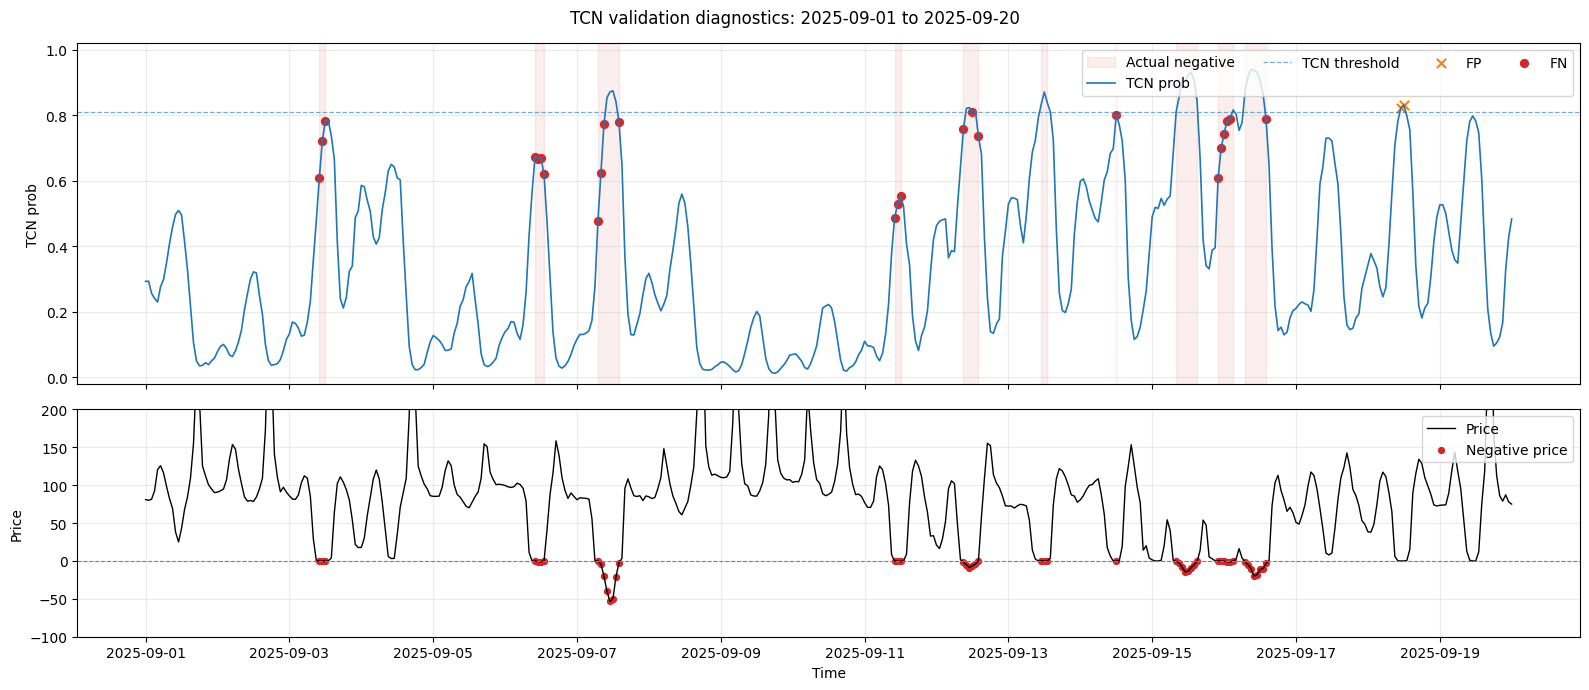

In [17]:
# 2025-09 TCN wrong predictions
valid_times = times_forecast[valid_mask]
valid_y = y_forecast[valid_mask]
valid_price = df["Price"].reindex(valid_times)

plot_start = pd.Timestamp("2025-09-01", tz="UTC")
plot_end = pd.Timestamp("2025-09-20", tz="UTC")
plot_mask = (valid_times >= plot_start) & (valid_times <= plot_end)

plot_times = valid_times[plot_mask]
plot_y = valid_y[plot_mask]
plot_price = valid_price.reindex(plot_times)

tcn_prob = avg_scores
tcn_pred = (tcn_prob >= best_threshold).astype(int)
tcn_fp = (tcn_pred == 1) & (valid_y == 0)
tcn_fn = (tcn_pred == 0) & (valid_y == 1)

tcn_prob_plot = tcn_prob[plot_mask]
tcn_fp_plot = tcn_fp[plot_mask]
tcn_fn_plot = tcn_fn[plot_mask]

fig, (tcn_ax, price_ax) = plt.subplots(
    2,
    1,
    figsize=(16, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1.5, 1]},
)

tcn_ax.fill_between(
    plot_times,
    -0.02,
    1.02,
    where=plot_y == 1,
    color="tab:red",
    alpha=0.08,
    step="mid",
    label="Actual negative",
)
tcn_ax.plot(plot_times, tcn_prob_plot, color="tab:blue", linewidth=1.2, label="TCN prob")
tcn_ax.axhline(best_threshold, color="tab:blue", linestyle="--", linewidth=0.9, alpha=0.6, label="TCN threshold")
tcn_ax.scatter(plot_times[tcn_fp_plot], tcn_prob_plot[tcn_fp_plot], color="tab:orange", marker="x", s=45, label="FP")
tcn_ax.scatter(plot_times[tcn_fn_plot], tcn_prob_plot[tcn_fn_plot], color="tab:red", marker="o", s=32, label="FN")
tcn_ax.set_ylabel("TCN prob")
tcn_ax.set_ylim(-0.02, 1.02)
tcn_ax.legend(loc="upper right", ncol=4)
tcn_ax.grid(True, alpha=0.25)

price_ax.plot(plot_times, plot_price, color="black", linewidth=1.0, label="Price")
price_ax.scatter(plot_times[plot_y == 1], plot_price[plot_y == 1], color="tab:red", s=18, label="Negative price")
price_ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
price_ax.set_ylim(-100, 200)
price_ax.set_ylabel("Price")
price_ax.set_xlabel("Time")
price_ax.legend(loc="upper right")
price_ax.grid(True, alpha=0.25)

fig.suptitle(f"TCN validation diagnostics: {plot_start.date()} to {plot_end.date()}")
plt.tight_layout()


## Guess: solar-related discrepancy


Solar summary by TCN valid error type


,count,positive,prob_mean,prob_median,price_mean,photovolt_mean,photovolt_median,forecast_shortwave_mean,actual_shortwave_mean,shortwave_error_mean,forecast_sunshine_mean,actual_sunshine_mean,sunshine_error_mean
error_type,,,,,,,,,,,,,
TP,129,129,0.875593,0.870626,-5.899070,24409.485504,26779.70,387.778876,422.182558,-34.403682,2415.094713,2633.308570,-218.213857
FP,51,0,0.843042,0.831995,6.992745,25204.950980,29174.74,414.133824,466.882353,-52.748529,2377.762789,2656.063848,-278.301059
FN,55,55,0.710608,0.743793,-1.153455,24603.302182,28872.29,361.036818,386.743182,-25.706364,2405.060177,2511.303136,-106.242959
TN,3437,0,0.231419,0.152456,92.904527,7340.851856,188.89,112.812882,126.747469,-13.934587,974.826988,1186.831170,-212.004182


Solar summary for TCN valid FP/FN by hour


count  photovolt_mean  forecast_shortwave_mean  \
hour error_type                                                   
7    FN              3    19871.753333               185.016667   
     FP              1    13826.400000               111.275000   
8    FN              7    29452.214286               369.453571   
     FP              3    28096.666667               368.675000   
9    FN              4    32162.137500               429.862500   
     FP              2    34454.925000               495.075000   
10   FN              6    35589.641667               508.325000   
     FP              7    32132.790000               514.407143   
11   FN              6    36346.958333               531.154167   
     FP              9    30475.542222               479.022222   
12   FN              7    33907.337143               516.267857   
     FP             10    34301.689000               586.332500   
13   FN              3    37734.476667               666.491667   
     FP              7    28808.924286               513.082143   
14   FN              6    25596.208333               460.383333   
     FP              2     9149.990000               221.362500   
15   FN              2    11437.805000               191.912500   
     FP              2    24517.985000               537.025000   

                 actual_shortwave_mean  shortwave_error_mean  
hour error_type                                               
7    FN                     189.916667             -4.900000  
     FP                     134.000000            -22.725000  
8    FN                     385.628571            -16.175000  
     FP                     432.675000            -64.000000  
9    FN                     438.856250             -8.993750  
     FP                     628.762500           -133.687500  
10   FN                     532.766667            -24.441667  
     FP                     592.125000            -77.717857  
11   FN                     611.075000            -79.920833  
     FP                     573.769444            -94.747222  
12   FN                     582.678571            -66.410714  
     FP                     637.817500            -51.485000  
13   FN                     659.016667              7.475000  
     FP                     534.507143            -21.425000  
14   FN                     484.450000            -24.066667  
     FP                     282.725000            -61.362500  
15   FN                     210.375000            -18.462500  
     FP                     546.812500             -9.787500

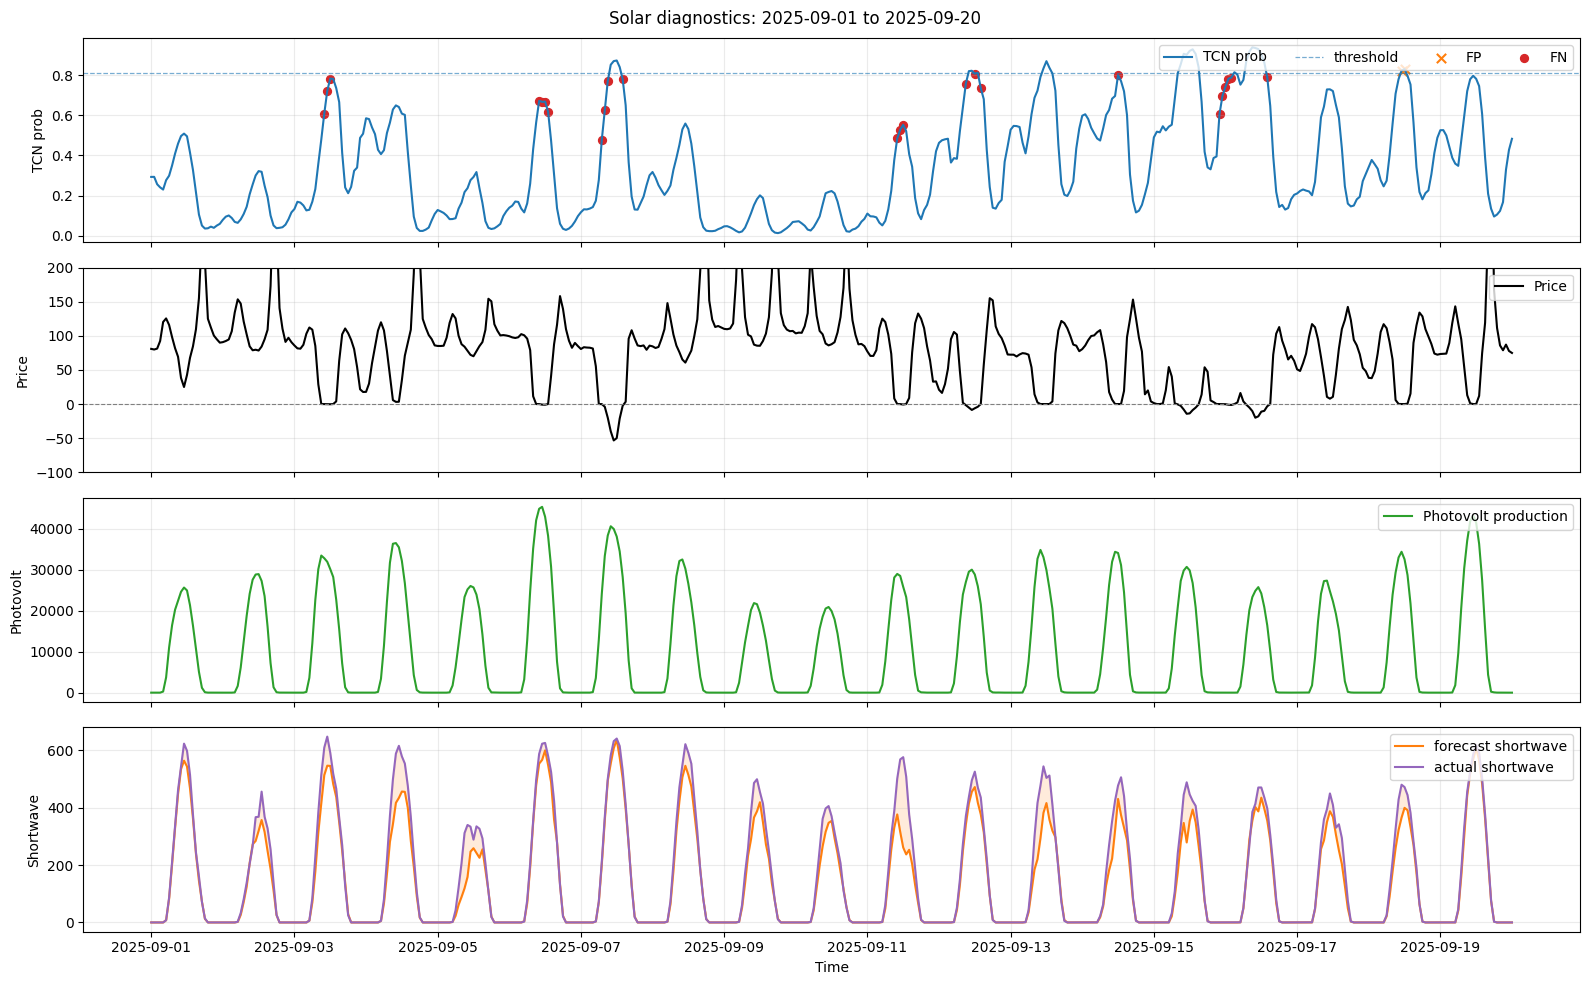

In [18]:
# Solar diagnostics for TCN valid errors.
plot_start = pd.Timestamp("2025-09-01", tz="UTC")
plot_end = pd.Timestamp("2025-09-20", tz="UTC")

tcn_valid_solar = tcn_valid_diag.copy()
tcn_valid_solar["error_type"] = np.select(
    [
        tcn_valid_solar["TP"].eq(1),
        tcn_valid_solar["FP"].eq(1),
        tcn_valid_solar["TN"].eq(1),
        tcn_valid_solar["FN"].eq(1),
    ],
    ["TP", "FP", "TN", "FN"],
    default="unknown",
)

target_times = pd.DatetimeIndex(tcn_valid_solar["timestamp"])
solar_weather_cols = [
    "south_solar__solar_radiation_avg",
    "east_solar__solar_radiation_avg",
]
sunshine_cols = [
    "south_solar__sunshine_duration_avg",
    "east_solar__sunshine_duration_avg",
]

tcn_valid_solar["Photovolt"] = df["Photovolt"].reindex(target_times).to_numpy()
tcn_valid_solar["actual_shortwave"] = df[solar_weather_cols].reindex(target_times).mean(axis=1).to_numpy()
tcn_valid_solar["forecast_shortwave"] = df_forecast[solar_weather_cols].reindex(target_times).mean(axis=1).to_numpy()
tcn_valid_solar["shortwave_error"] = tcn_valid_solar["forecast_shortwave"] - tcn_valid_solar["actual_shortwave"]
tcn_valid_solar["actual_sunshine"] = df[sunshine_cols].reindex(target_times).mean(axis=1).to_numpy()
tcn_valid_solar["forecast_sunshine"] = df_forecast[sunshine_cols].reindex(target_times).mean(axis=1).to_numpy()
tcn_valid_solar["sunshine_error"] = tcn_valid_solar["forecast_sunshine"] - tcn_valid_solar["actual_sunshine"]

solar_error_summary = tcn_valid_solar.groupby("error_type").agg(
    count=("y_true", "size"),
    positive=("y_true", "sum"),
    prob_mean=("y_prob", "mean"),
    prob_median=("y_prob", "median"),
    price_mean=("timestamp", lambda x: df["Price"].reindex(pd.DatetimeIndex(x)).mean()),
    photovolt_mean=("Photovolt", "mean"),
    photovolt_median=("Photovolt", "median"),
    forecast_shortwave_mean=("forecast_shortwave", "mean"),
    actual_shortwave_mean=("actual_shortwave", "mean"),
    shortwave_error_mean=("shortwave_error", "mean"),
    forecast_sunshine_mean=("forecast_sunshine", "mean"),
    actual_sunshine_mean=("actual_sunshine", "mean"),
    sunshine_error_mean=("sunshine_error", "mean"),
).reindex(["TP", "FP", "FN", "TN"])

solar_hour_mask = (
    tcn_valid_solar["error_type"].isin(["FP", "FN"])
    & tcn_valid_solar["hour"].between(7, 15)
)
solar_hour_summary = tcn_valid_solar[solar_hour_mask].groupby(["hour", "error_type"]).agg(
    count=("y_true", "size"),
    photovolt_mean=("Photovolt", "mean"),
    forecast_shortwave_mean=("forecast_shortwave", "mean"),
    actual_shortwave_mean=("actual_shortwave", "mean"),
    shortwave_error_mean=("shortwave_error", "mean"),
)

print("Solar summary by TCN valid error type")
display(solar_error_summary)
print("Solar summary for TCN valid FP/FN by hour")
display(solar_hour_summary)

solar_plot = tcn_valid_solar[(tcn_valid_solar["timestamp"] >= plot_start) & (tcn_valid_solar["timestamp"] <= plot_end)]
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

axes[0].plot(solar_plot["timestamp"], solar_plot["y_prob"], color="tab:blue", label="TCN prob")
axes[0].axhline(best_threshold, color="tab:blue", linestyle="--", linewidth=0.9, alpha=0.6, label="threshold")
axes[0].scatter(solar_plot.loc[solar_plot["FP"].eq(1), "timestamp"], solar_plot.loc[solar_plot["FP"].eq(1), "y_prob"], color="tab:orange", marker="x", s=45, label="FP")
axes[0].scatter(solar_plot.loc[solar_plot["FN"].eq(1), "timestamp"], solar_plot.loc[solar_plot["FN"].eq(1), "y_prob"], color="tab:red", marker="o", s=32, label="FN")
axes[0].set_ylabel("TCN prob")
axes[0].legend(loc="upper right", ncol=4)
axes[0].grid(True, alpha=0.25)

axes[1].plot(solar_plot["timestamp"], df["Price"].reindex(pd.DatetimeIndex(solar_plot["timestamp"])), color="black", label="Price")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_ylim(-100, 200)
axes[1].set_ylabel("Price")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.25)

axes[2].plot(solar_plot["timestamp"], solar_plot["Photovolt"], color="tab:green", label="Photovolt production")
axes[2].set_ylabel("Photovolt")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.25)

axes[3].plot(solar_plot["timestamp"], solar_plot["forecast_shortwave"], color="tab:orange", label="forecast shortwave")
axes[3].plot(solar_plot["timestamp"], solar_plot["actual_shortwave"], color="tab:purple", label="actual shortwave")
axes[3].fill_between(solar_plot["timestamp"], solar_plot["actual_shortwave"], solar_plot["forecast_shortwave"], color="tab:orange", alpha=0.15)
axes[3].set_ylabel("Shortwave")
axes[3].set_xlabel("Time")
axes[3].legend(loc="upper right")
axes[3].grid(True, alpha=0.25)

fig.suptitle(f"Solar diagnostics: {plot_start.date()} to {plot_end.date()}")
plt.tight_layout()


In [19]:
# Residual / price-context diagnostics for TCN valid errors.
tcn_context = tcn_valid_diag.copy()
tcn_context["error_type"] = np.select(
    [
        tcn_context["TP"].eq(1),
        tcn_context["FP"].eq(1),
        tcn_context["FN"].eq(1),
        tcn_context["TN"].eq(1),
    ],
    ["TP", "FP", "FN", "TN"],
    default="unknown",
)
tcn_context["hour"] = pd.DatetimeIndex(tcn_context["timestamp"]).hour

target_times = pd.DatetimeIndex(tcn_context["timestamp"])
price_series = df["Price"].sort_index()

renewable_cols = ["Photovolt", "Wind_onshore", "Wind_offshore", "Hydro", "Biomass", "Other_ren"]
conventional_cols = ["Lignite", "Fossil_gas", "Hard_coal", "Other_conv"]
extra_context_cols = ["Total_gen", "Residuals", "Wind_onshore", "Hard_coal"]

available_renewable_cols = [col for col in renewable_cols if col in df.columns]
available_conventional_cols = [col for col in conventional_cols if col in df.columns]
available_extra_context_cols = [col for col in extra_context_cols if col in df.columns]

tcn_context["Price"] = price_series.reindex(target_times).to_numpy()
tcn_context["Photovolt"] = df["Photovolt"].reindex(target_times).to_numpy()
tcn_context["Wind_offshore"] = df["Wind_offshore"].reindex(target_times).to_numpy()
tcn_context["renewable_total"] = df[available_renewable_cols].reindex(target_times).sum(axis=1).to_numpy()
tcn_context["conventional_total"] = df[available_conventional_cols].reindex(target_times).sum(axis=1).to_numpy()
tcn_context["renewable_minus_conventional"] = (
    tcn_context["renewable_total"] - tcn_context["conventional_total"]
)
for column in available_extra_context_cols:
    tcn_context[column] = df[column].reindex(target_times).to_numpy()

past_rows = []
for timestamp in target_times:
    context_end = timestamp - pd.Timedelta(hours=24)
    context_start = context_end - pd.Timedelta(hours=23)
    past_price = price_series.loc[context_start:context_end]
    past_rows.append({
        "past_24h_price_min": past_price.min(),
        "past_24h_price_mean": past_price.mean(),
        "past_24h_negative_hours": int((past_price < 0).sum()),
        "past_24h_below_20_hours": int((past_price < 20).sum()),
    })

past_context = pd.DataFrame(past_rows, index=tcn_context.index)
tcn_context = pd.concat([tcn_context, past_context], axis=1)


In [20]:
# Summary tables for TCN residual / price-context diagnostics.
from IPython.display import display

summary_aggs = {
    "count": ("y_true", "size"),
    "positive": ("y_true", "sum"),
    "prob_mean": ("y_prob", "mean"),
    "prob_median": ("y_prob", "median"),
    "price_mean": ("Price", "mean"),
    "price_median": ("Price", "median"),
    "past_24h_price_min_mean": ("past_24h_price_min", "mean"),
    "past_24h_price_mean_mean": ("past_24h_price_mean", "mean"),
    "past_24h_negative_hours_mean": ("past_24h_negative_hours", "mean"),
    "past_24h_below_20_hours_mean": ("past_24h_below_20_hours", "mean"),
    "photovolt_mean": ("Photovolt", "mean"),
    "wind_offshore_mean": ("Wind_offshore", "mean"),
    "renewable_total_mean": ("renewable_total", "mean"),
    "conventional_total_mean": ("conventional_total", "mean"),
    "renewable_minus_conventional_mean": ("renewable_minus_conventional", "mean"),
}
for column in ["Total_gen", "Residuals", "Wind_onshore", "Hard_coal"]:
    if column in tcn_context.columns:
        summary_aggs[f"{column}_mean"] = (column, "mean")
        summary_aggs[f"{column}_median"] = (column, "median")

context_summary = tcn_context.groupby("error_type").agg(**summary_aggs).reindex(["FP", "FN", "TN"])

hour_aggs = {
    "count": ("y_true", "size"),
    "prob_mean": ("y_prob", "mean"),
    "price_mean": ("Price", "mean"),
    "past_24h_price_min_mean": ("past_24h_price_min", "mean"),
    "past_24h_negative_hours_mean": ("past_24h_negative_hours", "mean"),
    "photovolt_mean": ("Photovolt", "mean"),
    "wind_offshore_mean": ("Wind_offshore", "mean"),
    "renewable_minus_conventional_mean": ("renewable_minus_conventional", "mean"),
}
for column in ["Total_gen", "Residuals", "Wind_onshore", "Hard_coal"]:
    if column in tcn_context.columns:
        hour_aggs[f"{column}_mean"] = (column, "mean")

context_hour_summary = (
    tcn_context[tcn_context["error_type"].isin(["FP", "FN"])]
    .groupby(["hour", "error_type"])
    .agg(**hour_aggs)
)

print("TCN valid context summary by error type")
display(context_summary)

print("TCN valid FP/FN context summary by hour")
display(context_hour_summary)


TCN valid context summary by error type


,count,positive,prob_mean,prob_median,price_mean,price_median,past_24h_price_min_mean,past_24h_price_mean_mean,past_24h_negative_hours_mean,past_24h_below_20_hours_mean,photovolt_mean,wind_offshore_mean,renewable_total_mean,conventional_total_mean,renewable_minus_conventional_mean,Wind_onshore_mean,Wind_onshore_median,Hard_coal_mean,Hard_coal_median
error_type,,,,,,,,,,,,,,,,,,,
FP,51,0,0.843042,0.831995,6.992745,1.32,11.498627,77.758145,1.372549,4.352941,25204.950980,3189.279216,50267.738235,7782.030588,42485.707647,16698.801961,15158.88,798.994902,584.75
FN,55,55,0.710608,0.743793,-1.153455,-0.10,15.692364,79.992667,1.818182,4.309091,24603.302182,3077.669636,50104.290909,6954.279455,43150.011455,17086.818545,13901.27,544.400727,451.75
TN,3437,0,0.231419,0.152456,92.904527,91.45,36.463334,87.829435,1.153913,2.885074,7340.851856,3067.714990,28043.216043,18669.870518,9373.345525,11800.068752,9713.16,2848.539692,2741.49


TCN valid FP/FN context summary by hour


count  prob_mean  price_mean  past_24h_price_min_mean  \
hour error_type                                                          
0    FN              2   0.755419   -0.135000                30.245000   
     FP              2   0.827586    2.055000                 3.255000   
1    FN              1   0.783404   -1.050000                -0.010000   
     FP              2   0.839493    1.010000                 0.510000   
2    FN              1   0.788726   -1.330000                -0.010000   
     FP              1   0.856291    0.340000                -0.010000   
3    FP              1   0.838177    0.100000                -0.010000   
6    FP              1   0.843169    3.010000                 0.000000   
7    FN              3   0.654765   -0.036667                23.380000   
     FP              1   0.875053    1.310000                 0.000000   
8    FN              7   0.702973   -0.752857                 9.520000   
     FP              3   0.867682    6.403333                 7.720000   
9    FN              4   0.756872   -6.190000                -0.960000   
     FP              2   0.853233    7.630000                -0.455000   
10   FN              6   0.680969   -0.898333                15.331667   
     FP              7   0.839824   13.037143                13.472857   
11   FN              6   0.713627   -0.330000                35.180000   
     FP              9   0.831407    8.924444                 6.464444   
12   FN              7   0.737427   -1.351429                30.882857   
     FP             10   0.843097    6.894000                16.796000   
13   FN              3   0.724716   -0.010000                18.796667   
     FP              7   0.847763    2.930000                27.232857   
14   FN              6   0.765169   -1.973333                -4.635000   
     FP              2   0.845502   23.395000                26.340000   
15   FN              2   0.715054   -0.305000                 8.260000   
     FP              2   0.854862    1.065000                -8.465000   
19   FN              1   0.526164   -0.090000                16.500000   
20   FN              1   0.520853   -0.050000                16.500000   
21   FN              1   0.564467   -0.340000                11.110000   
22   FN              2   0.699235   -0.380000                 0.360000   
23   FN              2   0.676547   -0.050000                30.245000   
     FP              1   0.811318    1.320000                 9.840000   

                 past_24h_negative_hours_mean  photovolt_mean  \
hour error_type                                                 
0    FN                              0.500000        8.505000   
     FP                              1.000000       15.195000   
1    FN                              1.000000        6.510000   
     FP                              1.000000       14.790000   
2    FN                              1.000000        6.320000   
     FP                              3.000000       14.340000   
3    FP                              3.000000       15.500000   
6    FP                              0.000000     7089.780000   
7    FN                              2.000000    19871.753333   
     FP                              0.000000    13826.400000   
8    FN                              1.571429    29452.214286   
     FP                              1.333333    28096.666667   
9    FN                              2.250000    32162.137500   
     FP                              2.500000    34454.925000   
10   FN                              2.000000    35589.641667   
     FP                              1.285714    32132.790000   
11   FN                              1.000000    36346.958333   
     FP                              1.333333    30475.542222   
12   FN                              2.000000    33907.337143   
     FP                              1.000000    34301.689000   
13   FN                              4.333333    37734.476667   
     

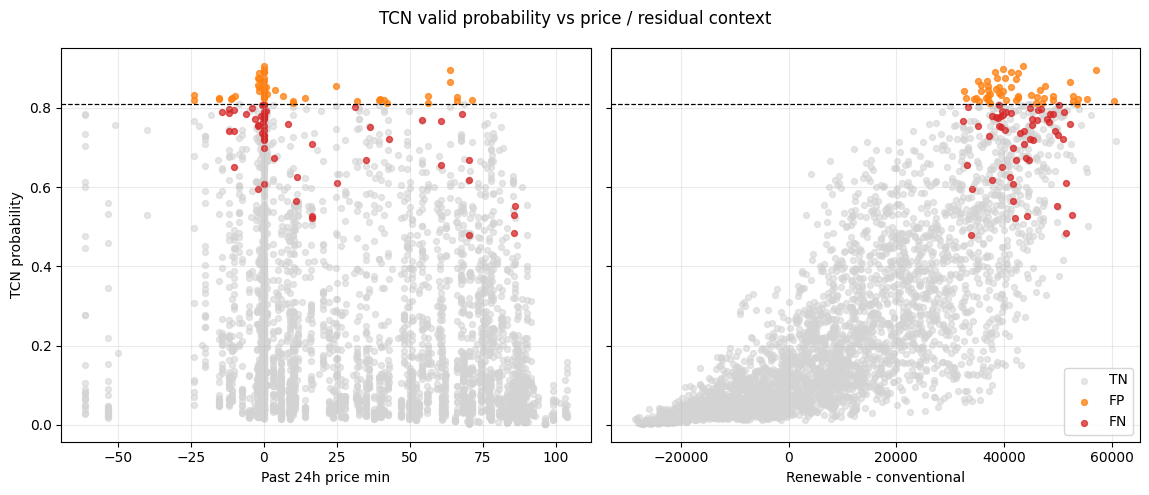

In [21]:
# Scatter diagnostics for TCN probability vs price / residual context.
plot_frame = tcn_context[tcn_context["error_type"].isin(["FP", "FN", "TN"])].copy()
colors = {"FP": "tab:orange", "FN": "tab:red", "TN": "lightgray"}
plot_order = ["TN", "FP", "FN"]
scatter_columns = [
    ("past_24h_price_min", "Past 24h price min"),
    ("Residuals", "Residuals"),
    ("Total_gen", "Total generation"),
    ("renewable_minus_conventional", "Renewable - conventional"),
]
scatter_columns = [(column, label) for column, label in scatter_columns if column in plot_frame.columns]

fig, axes = plt.subplots(1, len(scatter_columns), figsize=(5.8 * len(scatter_columns), 5), sharey=True)
if len(scatter_columns) == 1:
    axes = [axes]

for axis, (column, label) in zip(axes, scatter_columns):
    for error_type in plot_order:
        group = plot_frame[plot_frame["error_type"].eq(error_type)]
        if group.empty:
            continue
        axis.scatter(
            group[column],
            group["y_prob"],
            s=18,
            alpha=0.55 if error_type == "TN" else 0.75,
            color=colors[error_type],
            label=error_type,
        )
    axis.axhline(best_threshold, color="black", linestyle="--", linewidth=0.9)
    axis.set_xlabel(label)
    axis.grid(True, alpha=0.25)
axes[0].set_ylabel("TCN probability")
axes[-1].legend(loc="lower right")

fig.suptitle("TCN valid probability vs price / residual context")
plt.tight_layout()


TCN valid errors by price bucket


,price_bucket,error_type,count,prob_mean,price_mean
3,-50..-10,FN,1,0.771548,-20.090000
6,-10..-2,FN,7,0.751274,-3.988571
9,-2..0,FN,47,0.703255,-0.328298
10,-2..0,FP,16,0.853921,0.000000
11,-2..0,TN,28,0.691341,0.000000
13,0..2,FP,12,0.840561,0.724167
14,0..2,TN,41,0.632930,0.723171
16,2..10,FP,13,0.833508,4.203846
17,2..10,TN,97,0.630956,5.526082
19,10..20,FP,4,0.856412,13.465000


TCN valid FP severity


,count,price_mean,price_median,prob_mean,past_24h_price_min_mean,renewable_minus_conventional_mean
fp_severity,,,,,,
high_price_fp,6,39.905000,39.895,0.830737,8.283333,45891.300000
low_price_fp,17,6.382941,4.010,0.838898,7.944118,39726.118824
near_zero_fp,28,0.310357,0.000,0.848195,14.345714,43431.402500


TCN valid FN severity


,count,price_mean,price_median,prob_mean,past_24h_price_min_mean,renewable_minus_conventional_mean
fn_severity,,,,,,
deep_negative_fn,1,-20.090000,-20.09,0.771548,0.000000,45208.400000
moderate_negative_fn,7,-3.988571,-4.00,0.751274,-3.538571,45371.878571
near_zero_fn,47,-0.328298,-0.09,0.703255,18.890426,42775.299574


positive std: 45.27650043767439
negative std: 9.512708251715297


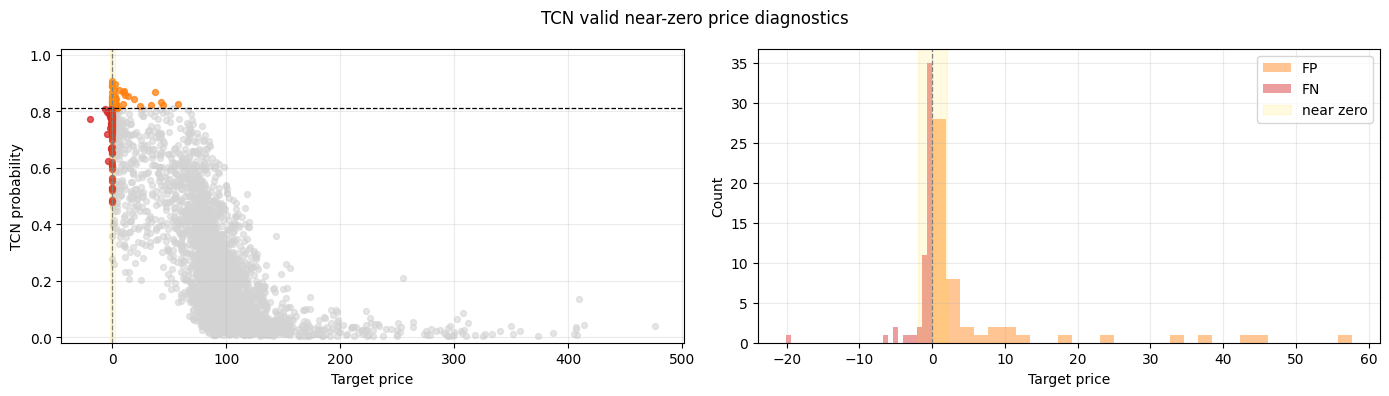

In [22]:
# Near-zero price severity diagnostics for TCN valid errors.
near_zero_context = tcn_context.copy()
near_zero_context["price_bucket"] = pd.cut(
    near_zero_context["Price"],
    bins=[-np.inf, -50, -10, -2, 0, 2, 10, 20, 50, np.inf],
    labels=["<-50", "-50..-10", "-10..-2", "-2..0", "0..2", "2..10", "10..20", "20..50", ">50"],
)
near_zero_context["fp_severity"] = np.where(
    near_zero_context["FP"].eq(1),
    np.select(
        [
            near_zero_context["Price"].le(2),
            near_zero_context["Price"].le(20),
            near_zero_context["Price"].gt(20),
        ],
        ["near_zero_fp", "low_price_fp", "high_price_fp"],
        default="not_fp",
    ),
    "not_fp",
)
near_zero_context["fn_severity"] = np.where(
    near_zero_context["FN"].eq(1),
    np.select(
        [
            near_zero_context["Price"].ge(-2),
            near_zero_context["Price"].ge(-20),
            near_zero_context["Price"].lt(-20),
        ],
        ["near_zero_fn", "moderate_negative_fn", "deep_negative_fn"],
        default="not_fn",
    ),
    "not_fn",
)

price_bucket_summary = (
    near_zero_context[near_zero_context["error_type"].isin(["FP", "FN", "TN"])]
    .groupby(["price_bucket", "error_type"], observed=False)
    .agg(
        count=("y_true", "size"),
        prob_mean=("y_prob", "mean"),
        price_mean=("Price", "mean"),
    )
    .reset_index()
)
price_bucket_summary = price_bucket_summary[price_bucket_summary["count"].gt(0)]

fp_severity_summary = near_zero_context[near_zero_context["FP"].eq(1)].groupby("fp_severity").agg(
    count=("y_true", "size"),
    price_mean=("Price", "mean"),
    price_median=("Price", "median"),
    prob_mean=("y_prob", "mean"),
    past_24h_price_min_mean=("past_24h_price_min", "mean"),
    renewable_minus_conventional_mean=("renewable_minus_conventional", "mean"),
)

fn_severity_summary = near_zero_context[near_zero_context["FN"].eq(1)].groupby("fn_severity").agg(
    count=("y_true", "size"),
    price_mean=("Price", "mean"),
    price_median=("Price", "median"),
    prob_mean=("y_prob", "mean"),
    past_24h_price_min_mean=("past_24h_price_min", "mean"),
    renewable_minus_conventional_mean=("renewable_minus_conventional", "mean"),
)

print("TCN valid errors by price bucket")
display(price_bucket_summary)
print("TCN valid FP severity")
display(fp_severity_summary)
print("TCN valid FN severity")
display(fn_severity_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
error_colors = {"FP": "tab:orange", "FN": "tab:red", "TN": "lightgray"}
for error_type in ["TN", "FP", "FN"]:
    group = near_zero_context[near_zero_context["error_type"].eq(error_type)]
    if group.empty:
        continue
    axes[0].scatter(
        group["Price"],
        group["y_prob"],
        s=18,
        alpha=0.55 if error_type == "TN" else 0.75,
        color=error_colors[error_type],
        label=error_type,
    )
axes[0].axhline(best_threshold, color="black", linestyle="--", linewidth=0.9)
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.9)
axes[0].axvspan(-2, 2, color="gold", alpha=0.12, label="near zero")
axes[0].set_xlabel("Target price")
axes[0].set_ylabel("TCN probability")
axes[0].set_ylim(-0.02, 1.02)
axes[0].grid(True, alpha=0.25)

for error_type in ["FP", "FN"]:
    group = near_zero_context[near_zero_context["error_type"].eq(error_type)]
    if group.empty:
        continue
    axes[1].hist(group["Price"], bins=30, alpha=0.45, color=error_colors[error_type], label=error_type)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=0.9)
axes[1].axvspan(-2, 2, color="gold", alpha=0.12, label="near zero")
axes[1].set_xlabel("Target price")
axes[1].set_ylabel("Count")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.25)

fig.suptitle("TCN valid near-zero price diagnostics")
plt.tight_layout()

print("positive std:", near_zero_context.loc[near_zero_context["Price"] > 0, "Price"].std())
print("negative std:", near_zero_context.loc[near_zero_context["Price"] < 0, "Price"].std())

In [24]:
# Negative-price event boundary diagnostics for TCN valid errors.
event_context = tcn_context.copy().sort_values("timestamp").reset_index(drop=True)
event_context["is_negative_price"] = event_context["Price"].lt(0)
event_context["event_id"] = pd.NA
event_context["event_phase"] = "outside"
event_context["hours_from_event_start"] = np.nan
event_context["hours_to_event_end"] = np.nan
event_context["nearest_event_distance_hours"] = np.nan

negative_runs = []
negative_rows = event_context[event_context["is_negative_price"]].copy()
if not negative_rows.empty:
    run_id = negative_rows["timestamp"].diff().ne(pd.Timedelta(hours=1)).cumsum()
    for event_id, group in negative_rows.groupby(run_id):
        start = group["timestamp"].min()
        end = group["timestamp"].max()
        duration = int(len(group))
        negative_runs.append({
            "event_id": int(event_id),
            "event_start": start,
            "event_end": end,
            "duration_hours": duration,
            "min_price": group["Price"].min(),
            "mean_price": group["Price"].mean(),
        })
        inside = event_context["timestamp"].between(start, end)
        event_context.loc[inside, "event_id"] = int(event_id)
        event_context.loc[inside, "hours_from_event_start"] = (
            event_context.loc[inside, "timestamp"] - start
        ) / pd.Timedelta(hours=1)
        event_context.loc[inside, "hours_to_event_end"] = (
            end - event_context.loc[inside, "timestamp"]
        ) / pd.Timedelta(hours=1)
        event_context.loc[inside, "event_phase"] = np.where(
            event_context.loc[inside, "hours_from_event_start"].eq(0),
            "start",
            np.where(event_context.loc[inside, "hours_to_event_end"].eq(0), "end", "middle"),
        )

for idx, row in event_context.iterrows():
    timestamp = row["timestamp"]
    distances = []
    for event in negative_runs:
        if timestamp < event["event_start"]:
            distances.append((event["event_start"] - timestamp) / pd.Timedelta(hours=1))
        elif timestamp > event["event_end"]:
            distances.append((timestamp - event["event_end"]) / pd.Timedelta(hours=1))
        else:
            distances.append(0.0)
    if distances:
        event_context.at[idx, "nearest_event_distance_hours"] = min(distances)

event_context.loc[
    event_context["event_phase"].eq("outside") & event_context["nearest_event_distance_hours"].le(3),
    "event_phase",
] = "near_event"

event_summary = event_context.groupby("event_phase").agg(
    size=("y_true", "size"),
    positive=("y_true", "sum"),
    TP=("TP", "sum"),
    FP=("FP", "sum"),
    FN=("FN", "sum"),
    TN=("TN", "sum"),
    prob_mean=("y_prob", "mean"),
    price_mean=("Price", "mean"),
    renewable_minus_conventional_mean=("renewable_minus_conventional", "mean"),
)
event_summary["precision"] = event_summary["TP"] / (event_summary["TP"] + event_summary["FP"]).replace(0, np.nan)
event_summary["recall"] = event_summary["TP"] / (event_summary["TP"] + event_summary["FN"]).replace(0, np.nan)
event_summary["f1"] = 2 * event_summary["TP"] / (2 * event_summary["TP"] + event_summary["FP"] + event_summary["FN"]).replace(0, np.nan)

event_error_summary = event_context[event_context["error_type"].isin(["FP", "FN"])].groupby(["event_phase", "error_type"]).agg(
    count=("y_true", "size"),
    prob_mean=("y_prob", "mean"),
    price_mean=("Price", "mean"),
    nearest_event_distance_mean=("nearest_event_distance_hours", "mean"),
    past_24h_price_min_mean=("past_24h_price_min", "mean"),
)

negative_event_summary = pd.DataFrame(negative_runs)
if not negative_event_summary.empty:
    event_detection = event_context[event_context["event_id"].notna()].groupby("event_id").agg(
        event_points=("y_true", "size"),
        detected_points=("y_pred", "sum"),
        missed_points=("FN", "sum"),
        prob_max=("y_prob", "max"),
        prob_mean=("y_prob", "mean"),
    )
    negative_event_summary = negative_event_summary.merge(event_detection, left_on="event_id", right_index=True, how="left")

print("Negative-price event summary")
display(negative_event_summary)
print("TCN valid metrics by event phase")
display(event_summary.drop(columns=["TP"]))
print("TCN valid FP/FN by event phase")
display(event_error_summary)


Negative-price event summary


,event_id,event_start,event_end,duration_hours,min_price,mean_price,event_points,detected_points,missed_points,prob_max,prob_mean
0,1,2025-07-04 10:00:00+00:00,2025-07-04 13:00:00+00:00,4,-1.56,-0.897500,4,4,0,0.887109,0.874452
1,2,2025-07-05 09:00:00+00:00,2025-07-05 14:00:00+00:00,6,-2.26,-1.586667,6,6,0,0.967587,0.949965
2,3,2025-07-19 11:00:00+00:00,2025-07-19 11:00:00+00:00,1,-0.01,-0.010000,1,1,0,0.815508,0.815508
3,4,2025-07-20 11:00:00+00:00,2025-07-20 11:00:00+00:00,1,-0.01,-0.010000,1,1,0,0.916588,0.916588
4,5,2025-08-03 08:00:00+00:00,2025-08-03 14:00:00+00:00,7,-10.08,-4.652857,7,6,1,0.882803,0.852083
5,6,2025-08-05 08:00:00+00:00,2025-08-05 15:00:00+00:00,8,-11.83,-5.500000,8,3,5,0.826115,0.761281
6,7,2025-08-06 08:00:00+00:00,2025-08-06 14:00:00+00:00,7,-11.79,-4.634286,7,5,2,0.883652,0.835508
7,8,2025-08-07 10:00:00+00:00,2025-08-07 13:00:00+00:00,4,-1.99,-0.602500,4,2,2,0.815914,0.792623
8,9,2025-08-08 11:00:00+00:00,2025-08-08 13:00:00+00:00,3,-0.02,-0.013333,3,0,3,0.784705,0.771540
9,10,2025-08-09 08:00:00+00:00,2025-08-09 14:00:00+00:00,7,-15.37,-6.042857,7,4,3,0.859716,0.786215


TCN valid metrics by event phase


,size,positive,FP,FN,TN,prob_mean,price_mean,renewable_minus_conventional_mean,precision,recall,f1
event_phase,,,,,,,,,,,
end,29,29,0,13,0,0.805933,-0.608621,44055.826552,1.0,0.551724,0.711111
middle,122,122,0,21,0,0.851320,-6.566393,46185.990410,1.0,0.827869,0.905830
near_event,192,0,21,0,171,0.578804,37.403646,33979.589479,0.0,NaN,0.000000
outside,3296,0,30,0,3266,0.220646,94.808249,8452.329636,0.0,NaN,0.000000
start,33,33,0,21,0,0.751573,-0.171818,44921.845455,1.0,0.363636,0.533333


TCN valid FP/FN by event phase


,,count,prob_mean,price_mean,nearest_event_distance_mean,past_24h_price_min_mean
event_phase,error_type,,,,,
end,FN,13,0.737424,-0.743077,0.000000,15.301538
middle,FN,21,0.716313,-2.388095,0.000000,14.641905
near_event,FP,21,0.853550,3.426190,1.476190,16.438571
outside,FP,30,0.835687,9.489333,52.466667,8.040667
start,FN,21,0.688303,-0.172857,0.000000,16.984762
